In [78]:
import sklearn as sk
import pandas as pd
import numpy as np
import seaborn as sns

In [79]:
df_final=pd.read_csv("Algerian Fire Clean.csv")

In [80]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    float64
 1   month        243 non-null    float64
 2   year         243 non-null    float64
 3   Temperature  243 non-null    float64
 4   RH           243 non-null    float64
 5   Ws           243 non-null    float64
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    str    
 14  Region       243 non-null    float64
dtypes: float64(14), str(1)
memory usage: 28.6 KB


In [81]:
df_final.drop(["day","month","year"],axis=1,inplace=True)

In [82]:
df_final["Classes"]=np.where(df_final["Classes"].str.contains("not fire"),0,1)

In [83]:
df_final["Classes"].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [84]:
X=df_final.drop('FWI',axis=1)
Y=df_final[['FWI']]

In [85]:
from sklearn.model_selection import train_test_split

In [86]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.30,random_state=42)

In [87]:
from sklearn.linear_model import LinearRegression as LR

<Axes: >

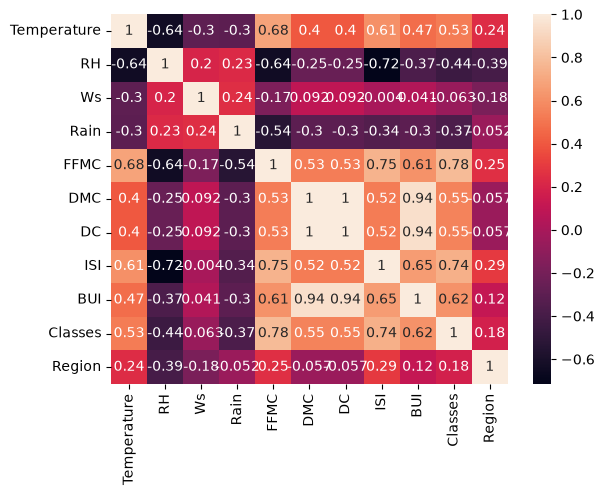

In [88]:
corr=X_train.corr()
sns.heatmap(corr,annot=True)

In [89]:
def corrrrr(dataset,threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]>threshold):
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [90]:
dropfeature=corrrrr(X_train,0.85)

In [ ]:
X_train.drop(dropfeature,axis=1,inplace=True)
X_test.drop(dropfeature,axis=1,inplace=True)

In [92]:
from sklearn.preprocessing import StandardScaler

In [93]:
Scale=StandardScaler()

In [94]:
X_train=Scale.fit_transform(X_train)
X_test=Scale.transform(X_test)